#### Cell 1: Load the Data

In [4]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx, subgraph
import torch_geometric.data as pyg_data

# Load our processed graph
data = torch.load("../data/processed/elliptic_graph.pt", weights_only=False)
print(f"Total Nodes (Transactions): {data.num_nodes}")
print(f"Total Edges (Payment Flows): {data.num_edges}")
print(f"Number of Features: {data.num_features}")


# Cell 4: Sanity check for missing values (NaNs)
missing_features = torch.isnan(data.x).sum().item()
missing_labels = torch.isnan(data.y).sum().item()

print(f"Missing values in features: {missing_features}")
print(f"Missing values in labels: {missing_labels}")

Total Nodes (Transactions): 203769
Total Edges (Payment Flows): 234355
Number of Features: 165
Missing values in features: 0
Missing values in labels: 0


#### Cell 2: Visualize the Class Imbalance 

Fraud detection is notoriously imbalanced. This bar chart proves why we had to use class weights in our train.py loss function!

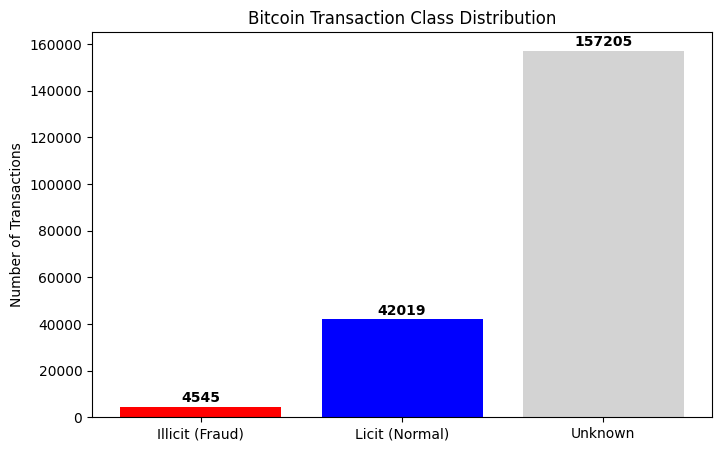

In [2]:
labels = data.y.numpy()
# Map: 0=Illicit, 1=Licit, 2=Unknown
counts = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(
    ["Illicit (Fraud)", "Licit (Normal)", "Unknown"],
    counts.values,
    color=["red", "blue", "lightgray"],
)
plt.title("Bitcoin Transaction Class Distribution")
plt.ylabel("Number of Transactions")

# Add the text counts above the bars
for i, v in enumerate(counts.values):
    plt.text(i, v + 2000, str(v), ha="center", fontweight="bold")

plt.show()


#### Cell 3: The "Money Shot" (Network Visualization) 

This cell isolates a single moment in time (Time Step 1) and draws the actual Bitcoin transaction network.

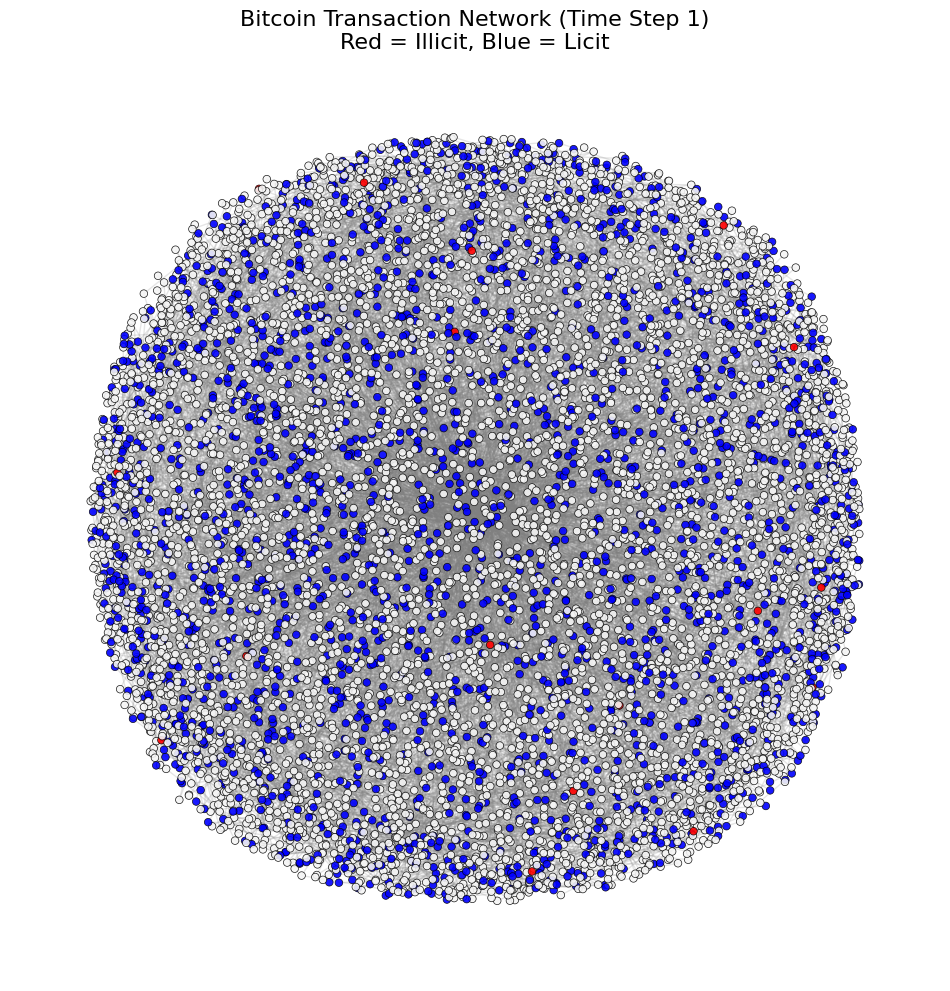

In [3]:
# 1. Isolate nodes from Time Step 1
time_step_1_mask = data.time_step == 1
ts1_nodes = time_step_1_mask.nonzero(as_tuple=False).view(-1)

# 2. Extract the subgraph (only edges between Time Step 1 nodes)
ts1_edge_index, _ = subgraph(ts1_nodes, data.edge_index, relabel_nodes=True)

# 3. Create a temporary PyG Data object and convert to NetworkX
ts1_data = pyg_data.Data(edge_index=ts1_edge_index, num_nodes=ts1_nodes.size(0))
G = to_networkx(ts1_data, to_undirected=True)

# 4. Color map: Red for Fraud, Blue for Normal, Gray for Unknown
ts1_labels = data.y[ts1_nodes].numpy()
color_map = []
for label in ts1_labels:
    if label == 0:
        color_map.append("red")
    elif label == 1:
        color_map.append("blue")
    else:
        color_map.append("whitesmoke")

# 5. Plot the Graph
plt.figure(figsize=(12, 12))
plt.title(
    "Bitcoin Transaction Network (Time Step 1)\nRed = Illicit, Blue = Licit",
    fontsize=16,
)

# The spring layout simulates physical springs between connected nodes
pos = nx.spring_layout(G, seed=42, k=0.15)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=30,
    node_color=color_map,
    alpha=0.9,
    edgecolors="black",
    linewidths=0.5,
)
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color="gray")
plt.axis("off")
plt.show()
